# Eksperimen SML — Titanic Survival Prediction

**Nama:** Fareynaldi Affan  
**Kelas:** Membangun Sistem Machine Learning (Dicoding)

Eksperimen prediksi keselamatan penumpang Titanic (klasifikasi biner `Survived`). Tahapan: **Data Loading → Exploratory Data Analysis → Data Preprocessing**, lalu menyimpan data yang siap dilatih.

## Import Library

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="darkgrid")
pd.set_option('display.max_columns', None)
print('Library berhasil dimuat.')

Library berhasil dimuat.


## 1. Data Loading

Membaca berkas mentah `titanic_raw.csv`.

In [2]:
data = pd.read_csv('../titanic_raw.csv')
print('Dimensi data:', data.shape)
data.head()

Dimensi data: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 2. Exploratory Data Analysis

Menelaah statistik, sebaran target, pengaruh gender/kelas terhadap keselamatan, distribusi usia, serta memeriksa nilai hilang.

### 2.1 Statistik Deskriptif

In [4]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 2.2 Proporsi Penumpang Selamat

Survived
0    549
1    342
Name: count, dtype: int64

Persentase selamat: 38.4%


/var/folders/2g/bjstxd7n05x6_kp44td0fhm40000gn/T/ipykernel_18141/3187892279.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=data, palette='Set2')


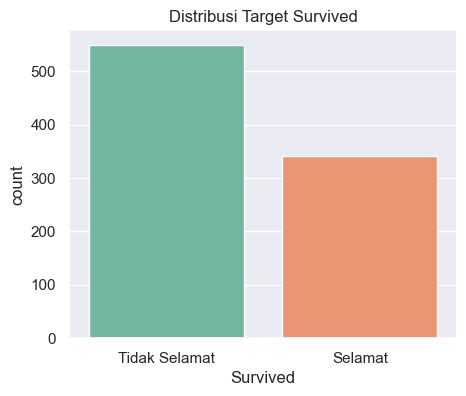

In [5]:
survival = data['Survived'].value_counts()
print(survival)
print('\nPersentase selamat: {:.1f}%'.format(100 * data['Survived'].mean()))

plt.figure(figsize=(5, 4))
sns.countplot(x='Survived', data=data, palette='Set2')
plt.xticks([0, 1], ['Tidak Selamat', 'Selamat'])
plt.title('Distribusi Target Survived')
plt.show()

### 2.3 Keselamatan Berdasarkan Gender & Kelas Tiket

/var/folders/2g/bjstxd7n05x6_kp44td0fhm40000gn/T/ipykernel_18141/3850253103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=data, ax=axes[0], palette='pastel')
/var/folders/2g/bjstxd7n05x6_kp44td0fhm40000gn/T/ipykernel_18141/3850253103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=data, ax=axes[1], palette='pastel')


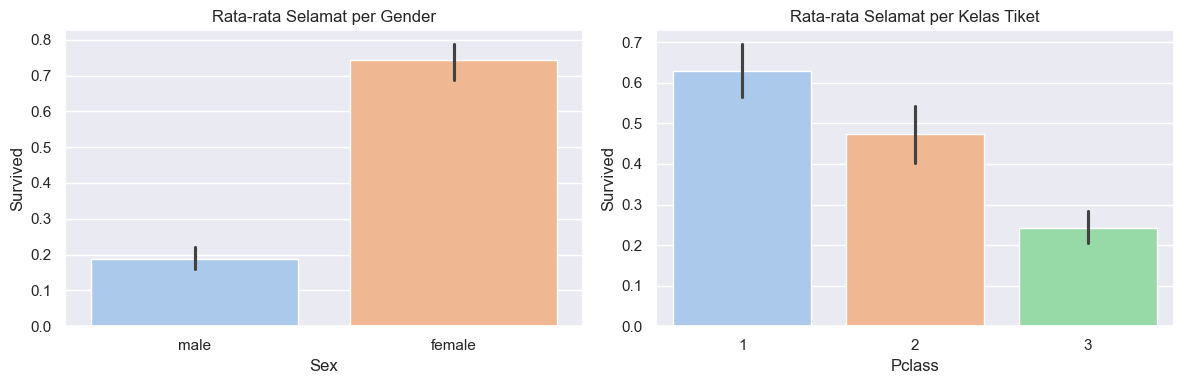

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Sex', y='Survived', data=data, ax=axes[0], palette='pastel')
axes[0].set_title('Rata-rata Selamat per Gender')
sns.barplot(x='Pclass', y='Survived', data=data, ax=axes[1], palette='pastel')
axes[1].set_title('Rata-rata Selamat per Kelas Tiket')
plt.tight_layout()
plt.show()

### 2.4 Distribusi Usia terhadap Keselamatan

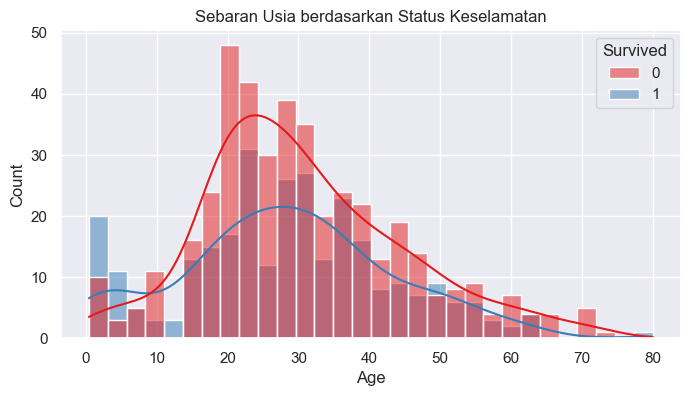

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x='Age', hue='Survived', bins=30, kde=True, palette='Set1')
plt.title('Sebaran Usia berdasarkan Status Keselamatan')
plt.show()

### 2.5 Pemeriksaan Nilai Hilang

In [8]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Kolom dengan nilai hilang:')
print(missing)
print('\nPersentase (%):')
print((missing / len(data) * 100).round(1))

Kolom dengan nilai hilang:
Cabin       687
Age         177
Embarked      2
dtype: int64

Persentase (%):
Cabin       77.1
Age         19.9
Embarked     0.2
dtype: float64


### 2.6 Korelasi Fitur Numerik

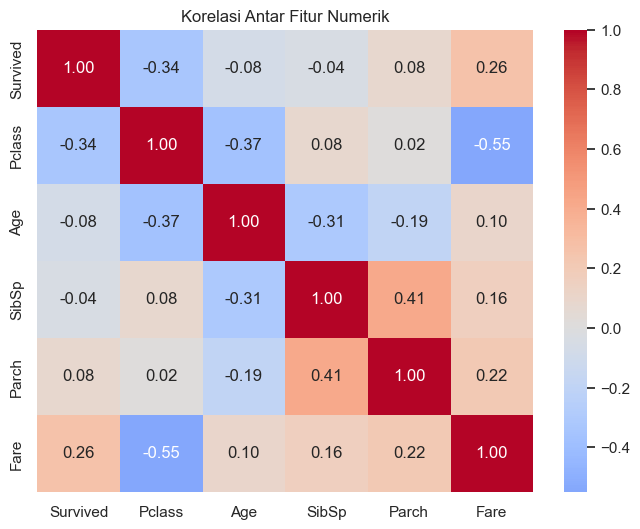

In [9]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(8, 6))
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

## 3. Data Preprocessing

Langkah-langkah:
1. Membuang kolom tak informatif / terlalu banyak kosong (`PassengerId`, `Name`, `Ticket`, `Cabin`).
2. Mengisi `Age` (median) dan `Embarked` (modus).
3. Encoding `Sex` (biner) dan `Embarked` (one-hot).
4. Standardisasi seluruh fitur, lalu menyimpan `titanic_preprocessing.csv`.

### 3.1 Membuang Kolom Tak Relevan

In [10]:
work = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
work.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 3.2 Imputasi Nilai Hilang

In [11]:
work['Age'] = work['Age'].fillna(work['Age'].median())
work['Embarked'] = work['Embarked'].fillna(work['Embarked'].mode()[0])
print('Sisa nilai hilang:', int(work.isnull().sum().sum()))

Sisa nilai hilang: 0


### 3.3 Encoding Variabel Kategorikal

In [12]:
work['Sex'] = work['Sex'].map({'male': 0, 'female': 1})
work = pd.get_dummies(work, columns=['Embarked'], drop_first=True)
# konversi kolom boolean hasil get_dummies ke integer
bool_cols = work.select_dtypes('bool').columns
work[bool_cols] = work[bool_cols].astype(int)
work.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


### 3.4 Standardisasi & Simpan Data Siap Latih

In [13]:
target = work['Survived']
features = work.drop(columns=['Survived'])

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
scaled['Survived'] = target.values

scaled.to_csv('titanic_preprocessing.csv', index=False)
print('Disimpan: titanic_preprocessing.csv', scaled.shape)
scaled.head()

Disimpan: titanic_preprocessing.csv (891, 9)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Survived
0,0.827377,-0.737695,-0.565736,0.432793,-0.473674,-0.502445,-0.307562,0.615838,0
1,-1.566107,1.355574,0.663861,0.432793,-0.473674,0.786845,-0.307562,-1.623803,1
2,0.827377,1.355574,-0.258337,-0.474545,-0.473674,-0.488854,-0.307562,0.615838,1
3,-1.566107,1.355574,0.433312,0.432793,-0.473674,0.420730,-0.307562,0.615838,1
4,0.827377,-0.737695,0.433312,-0.474545,-0.473674,-0.486337,-0.307562,0.615838,0


### 3.5 Verifikasi Kesiapan Train/Test

In [14]:
X = scaled.drop(columns=['Survived'])
y = scaled['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
print('Train:', X_tr.shape, '| Test:', X_te.shape)
print('Fitur akhir:', list(X.columns))

Train: (712, 8) | Test: (179, 8)
Fitur akhir: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


## Kesimpulan

- Data 891 penumpang; sekitar 38% selamat (target sedikit tidak seimbang).
- Gender dan kelas tiket sangat berpengaruh terhadap keselamatan.
- `Cabin` dibuang (mayoritas kosong); `Age` & `Embarked` diimputasi.
- Fitur kategorikal di-encode dan seluruh fitur distandardisasi.
- `titanic_preprocessing.csv` siap dipakai pada tahap pemodelan (Kriteria 2).